In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_day = pd.read_csv('E:\Gen AI\AQI_Analysis\Dataset\city_day.csv')

In [4]:
df_day.sample(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
19644,Kolkata,2019-12-13,101.93,185.67,17.20,43.64,60.84,23.41,1.01,13.10,44.65,20.86,21.11,2.67,193.0,Moderate
5565,Bengaluru,2018-06-25,51.82,70.62,6.93,14.77,16.14,39.41,1.01,4.79,14.73,0.36,1.09,NaN,87.0,Satisfactory
317,Ahmedabad,2015-11-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25907,Shillong,2020-02-28,17.24,24.88,0.79,2.44,1.04,2.49,0.24,3.09,25.66,405.21,405.05,NaN,42.0,Good
1135,Ahmedabad,2018-02-09,103.17,NaN,108.99,173.67,166.23,NaN,108.99,125.46,42.09,0.74,5.81,3.21,1423.0,Severe


In [5]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [6]:
df_day.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


### Observation
The dataset has many pollution columns, but a lot of them have missing values. So before doing any comparison, cleaning the data is important.



In [7]:
null_before_remove_rows_columns=df_day.isnull().sum()

In [8]:
df_day

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [9]:
df_day.isnull().mean()*100

City           0.000000
Date           0.000000
PM2.5         15.570079
PM10          37.723071
NO            12.129626
NO2           12.139785
NOx           14.171549
NH3           34.973418
CO             6.972334
SO2           13.050692
O3            13.619586
Benzene       19.041008
Toluene       27.229014
Xylene        61.322001
AQI           15.851139
AQI_Bucket    15.851139
dtype: float64

In [10]:
df_day=df_day.drop('Xylene',axis=1)

In [11]:
df_day.sample(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
7492,Brajrajnagar,2020-05-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21332,Lucknow,2019-01-26,58.65,NaN,13.40,22.82,22.42,28.83,1.14,6.41,15.62,0.03,0.17,208.0,Poor
11040,Delhi,2017-03-22,120.88,405.64,86.41,69.31,31.85,49.03,0.58,28.88,20.88,4.89,10.60,390.0,Very Poor
26244,Talcher,2018-07-20,25.77,83.04,26.72,3.96,25.24,21.20,2.62,70.78,20.80,0.00,0.00,110.0,Moderate
13398,Gurugram,2018-08-21,54.44,NaN,10.68,24.04,19.01,NaN,0.54,6.08,18.51,1.36,NaN,139.0,Moderate


In [12]:
df_day = df_day[df_day['City'].str.lower() != 'mumbai']

In [13]:
df_day

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,54.0,Satisfactory


In [14]:
df_day.sample(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
15011,Hyderabad,2016-03-09,50.81,86.52,7.07,13.18,18.89,10.29,1.33,9.26,41.84,0.92,4.24,118.0,Moderate
13728,Gurugram,2019-07-17,31.41,67.29,9.24,10.37,12.03,NaN,0.45,10.72,26.52,1.98,6.00,73.0,Satisfactory
10718,Delhi,2016-05-04,103.08,297.94,18.52,61.77,72.09,49.53,1.44,26.13,91.18,4.30,12.28,309.0,Very Poor
28015,Thiruvananthapuram,2020-05-09,15.85,39.05,26.69,11.50,35.24,26.23,0.58,5.46,26.44,NaN,NaN,63.0,Satisfactory
25301,Patna,2019-05-08,78.57,NaN,6.85,5.45,5.57,NaN,1.33,39.86,71.68,1.88,16.32,190.0,Moderate


In [15]:
df_day = df_day.dropna(subset=df_day.columns.difference(['City','Date']),how='all')

In [16]:
after_remove_row_column = df_day.isnull().sum()

In [17]:
df_day.isnull().mean()*100

City           0.000000
Date           0.000000
PM2.5          7.712004
PM10          32.632705
NO             3.764283
NO2            3.733710
NOx            8.908167
NH3           28.123209
CO             2.594871
SO2            4.887836
O3             5.560439
Benzene       15.508083
Toluene       21.756411
AQI            7.994803
AQI_Bucket     7.994803
dtype: float64

### Observation
Dropping Xylene makes sense here because too much of it is missing. Removing rows where almost everything is empty also helps keep only useful records.

Mumbai is removed in this notebook, so all later city results are for the remaining cities only.



<Axes: ylabel='Density'>

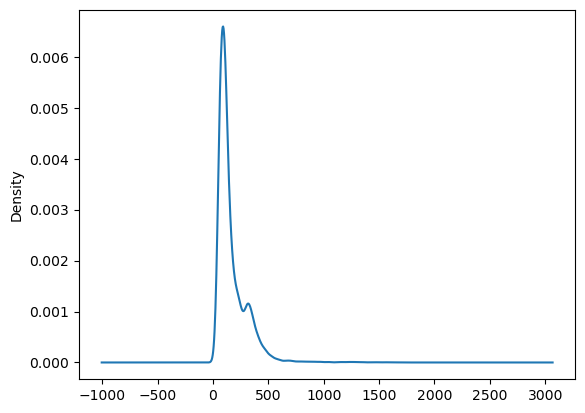

In [18]:
df_day['AQI'].plot(kind='kde')

### Observation
This AQI curve is not balanced. Most values are in the lower range, but some days have much higher AQI, so the data is right-skewed.



In [19]:
df_day['AQI'].skew()

3.3564998475262433

In [20]:
df_day['AQI_Bucket'].value_counts()

AQI_Bucket
Moderate        8544
Satisfactory    7796
Poor            2746
Very Poor       2336
Severe          1338
Good            1315
Name: count, dtype: int64

In [21]:
df_day['AQI_Bucket'].isnull().mean()*100

7.994802613979441

In [22]:
df_day['AQI_Bucket'].info()

<class 'pandas.core.series.Series'>
Index: 26167 entries, 0 to 29530
Series name: AQI_Bucket
Non-Null Count  Dtype 
--------------  ----- 
24075 non-null  object
dtypes: object(1)
memory usage: 408.9+ KB


### Observation
AQI_Bucket also has missing values, so category-based results may not cover every row. Still, the bucket counts give a quick idea of how often air quality falls into each level.



<Axes: ylabel='Density'>

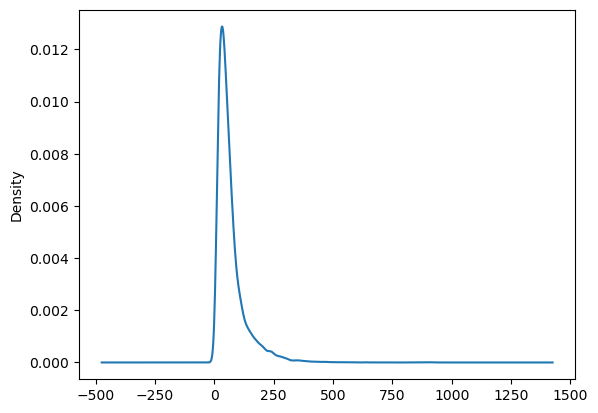

In [23]:
df_day['PM2.5'].plot(kind='kde')


### Observation
PM2.5 values are spread unevenly. A lot of days stay in a lower range, but some days go much higher.



<Axes: ylabel='Density'>

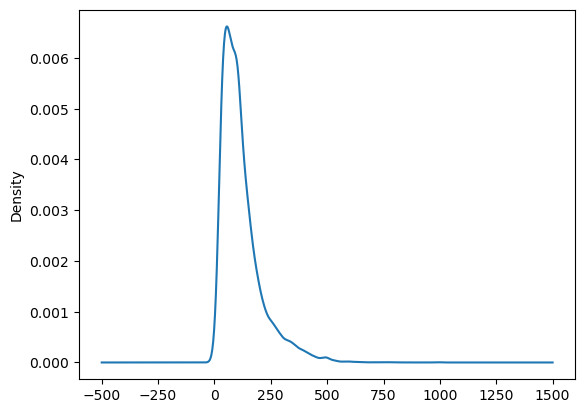

In [24]:
df_day['PM10'].plot(kind='kde')


### Observation
PM10 also looks uneven and stretched to one side. This means a few high-pollution days are pulling the curve.



<Axes: ylabel='Density'>

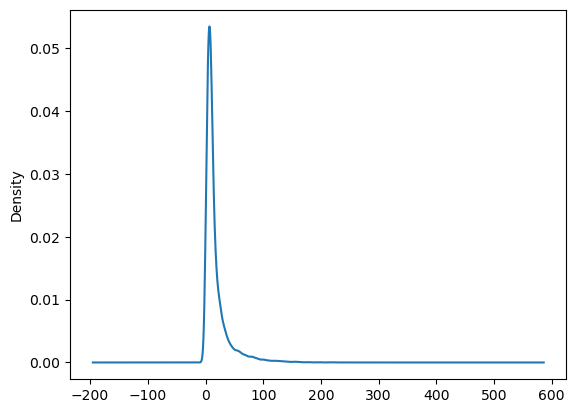

In [25]:
df_day['NO'].plot(kind='kde')

### Observation
NO values are mostly concentrated in a smaller range, with some higher values showing up less often.



<Axes: ylabel='Density'>

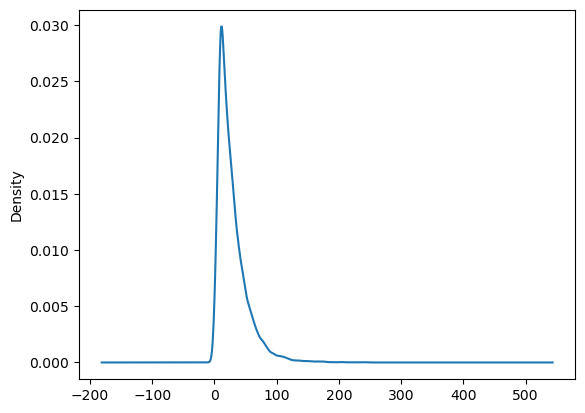

In [26]:
df_day['NO2'].plot(kind='kde')


### Observation
NO2 does not look evenly spread either. There are some days with much higher values than normal.



<Axes: ylabel='Density'>

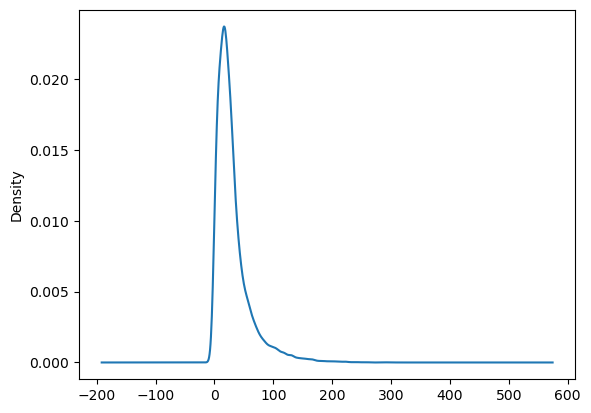

In [27]:
df_day['NOx'].plot(kind='kde')


### Observation
NOx shows a long spread, which suggests some strong pollution spikes in the data.



<Axes: ylabel='Density'>

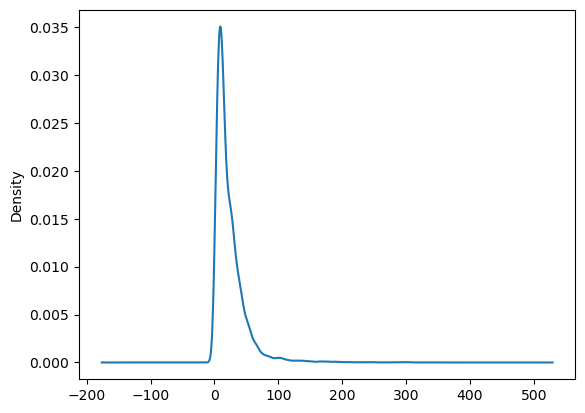

In [28]:
df_day['NH3'].plot(kind='kde')


### Observation
NH3 is also skewed. Most readings seem lower, but a smaller set of days has much higher values.



<Axes: >

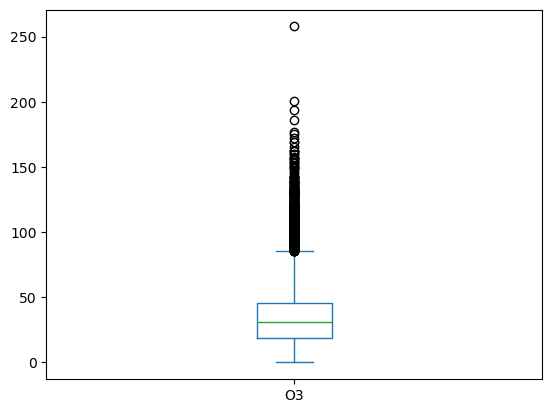

In [29]:
df_day['O3'].plot(kind='box')


### Observation
The O3 box plot shows outliers. That means a few days have ozone levels much different from the usual range.



In [30]:
for col in df_day.select_dtypes(include='number').columns.drop('AQI'):
    df_day[col] = df_day.groupby('City')[col].transform('median')

C:\Users\DELL\AppData\Local\Temp\ipykernel_7392\403230553.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day[col] = df_day.groupby('City')[col].transform('median')
C:\Users\DELL\AppData\Local\Temp\ipykernel_7392\403230553.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day[col] = df_day.groupby('City')[col].transform('median')
C:\Users\DELL\AppData\Local\Temp\ipykernel_7392\403230553.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

In [31]:
df_day.isnull().sum()

City             0
Date             0
PM2.5            0
PM10          1991
NO               0
NO2              0
NOx            947
NH3           1559
CO               0
SO2              0
O3             159
Benzene       2488
Toluene       3623
AQI           2092
AQI_Bucket    2092
dtype: int64

In [32]:
len(df_day['Toluene'])

26167

In [33]:
# for col in df_day.select_dtypes(include='number').columns.drop('AQI'):
    # df_day[col] = df_day.groupby('City')[col].transform('median')

for col in df_day.select_dtypes(include='number').columns.drop('AQI'):
    df_day[col] = df_day[col].fillna(df_day[col].median())

C:\Users\DELL\AppData\Local\Temp\ipykernel_7392\1847589167.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day[col] = df_day[col].fillna(df_day[col].median())


In [34]:
df_day.isnull().sum()

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
AQI           2092
AQI_Bucket    2092
dtype: int64

### Observation
After filling the missing values, the dataset becomes easier to use for charts and comparisons. This step makes the later analysis more complete, but the filled values are estimates, not original readings.



<Axes: xlabel='City'>

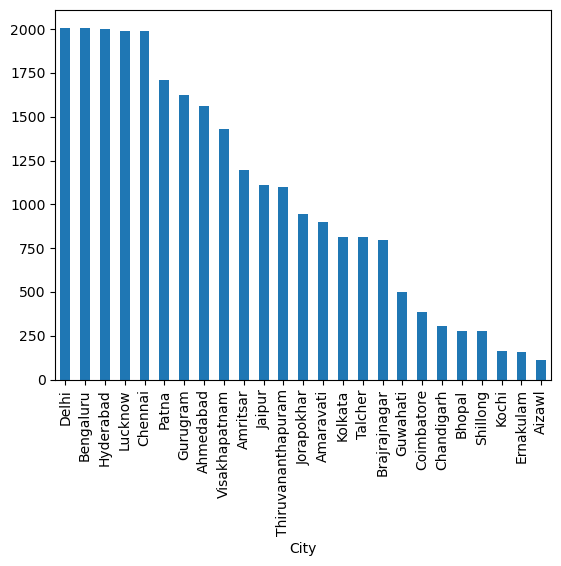

In [35]:
df_day['City'].value_counts().plot(kind='bar')

### Observation
This bar chart shows the data is not equally spread across cities. Some cities have many more records than others.



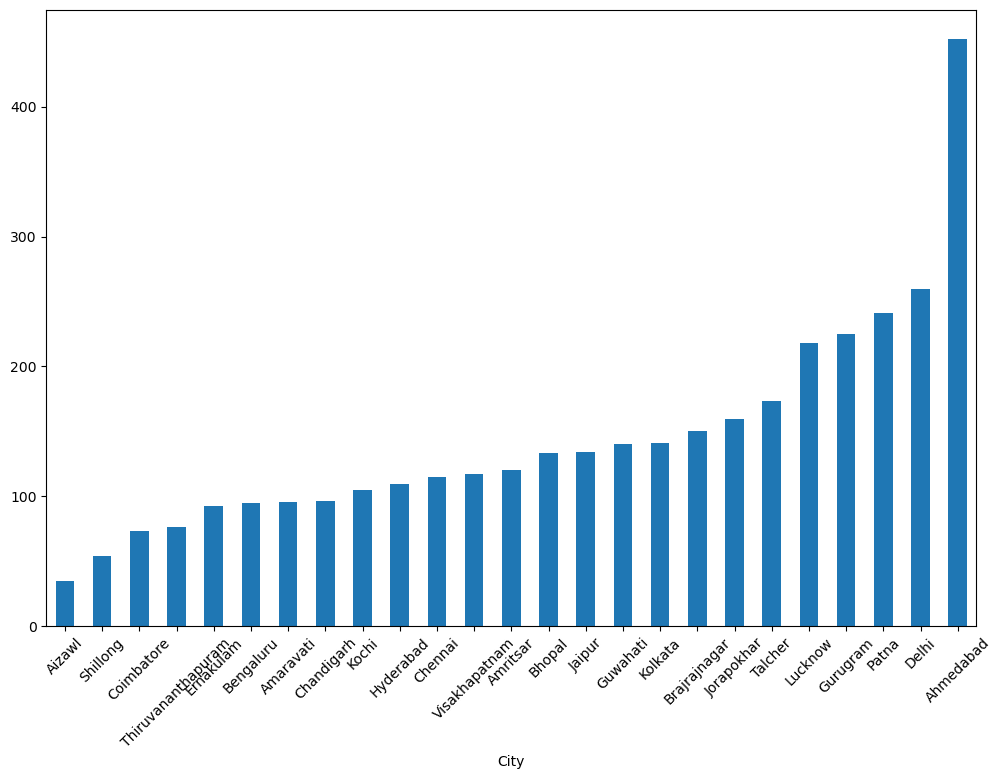

In [36]:
city_aqi = df_day.groupby('City')['AQI'].mean().sort_values(ascending=True)

plt.figure(figsize=(12,8))
city_aqi.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

### Observation
Average AQI changes a lot from city to city. Some cities look clearly cleaner, while others stay on the higher side.



In [37]:
df_day[df_day['AQI'] == df_day['AQI'].max()]

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
1145,Ahmedabad,2018-02-19,58.37,107.96,16.28,47.19,39.51,16.59,16.245,46.78,39.51,3.87,23.95,2049.0,Severe


<Axes: >

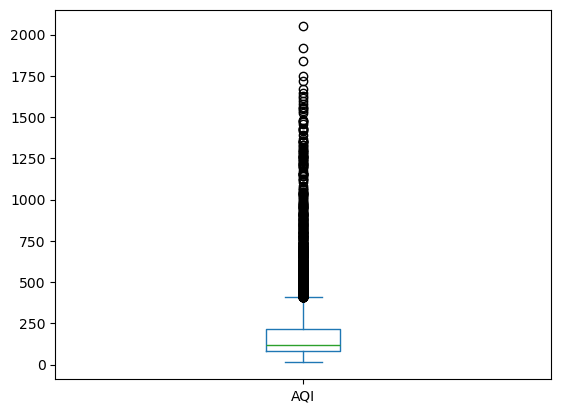

In [38]:
df_day['AQI'].plot(kind='box')

### Observation
The AQI box plot shows outliers, so a few days had very bad air compared to the usual pattern.



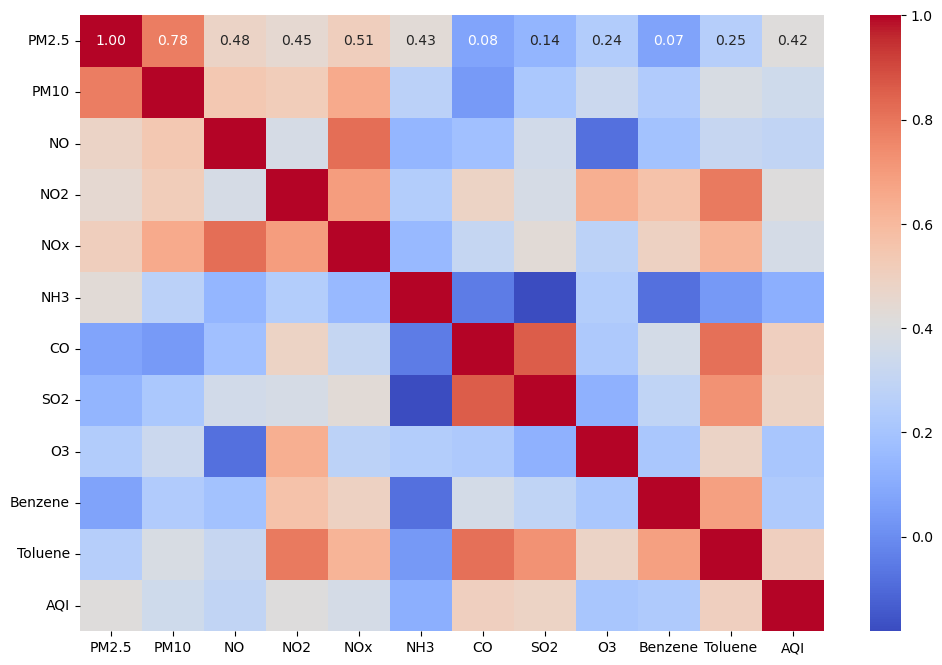

In [39]:
plt.figure(figsize=(12,8))
sns.heatmap(df_day.select_dtypes(include='number').corr(), 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')
plt.show()

### Observation
The heatmap shows which pollution measures move together. Darker strong values mean a stronger relationship.



In [40]:
##converting the date object to different column and in date time series

df_day.dtypes

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
AQI           float64
AQI_Bucket     object
dtype: object

In [41]:
df_day['Date'] = pd.to_datetime(df_day['Date'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_7392\1215500205.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['Date'] = pd.to_datetime(df_day['Date'])


In [42]:
df_day.dtypes

City                  object
Date          datetime64[ns]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
AQI                  float64
AQI_Bucket            object
dtype: object

In [43]:
season_map = {
    1: 'Winter', 2: 'Winter', 3: 'Summer',
    4: 'Summer', 5: 'Summer', 6: 'Summer',
    7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
    10: 'Monsoon', 11: 'Winter', 12: 'Winter'
}

df_day['Season'] = df_day['Date'].dt.month.map(season_map)

C:\Users\DELL\AppData\Local\Temp\ipykernel_7392\2910298208.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['Season'] = df_day['Date'].dt.month.map(season_map)


In [44]:
df_day

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,Season
0,Ahmedabad,2015-01-01,58.37,107.960,16.28,47.19,39.51,16.59,16.245,46.78,39.51,3.87,23.95,NaN,NaN,Winter
1,Ahmedabad,2015-01-02,58.37,107.960,16.28,47.19,39.51,16.59,16.245,46.78,39.51,3.87,23.95,NaN,NaN,Winter
2,Ahmedabad,2015-01-03,58.37,107.960,16.28,47.19,39.51,16.59,16.245,46.78,39.51,3.87,23.95,NaN,NaN,Winter
3,Ahmedabad,2015-01-04,58.37,107.960,16.28,47.19,39.51,16.59,16.245,46.78,39.51,3.87,23.95,NaN,NaN,Winter
4,Ahmedabad,2015-01-05,58.37,107.960,16.28,47.19,39.51,16.59,16.245,46.78,39.51,3.87,23.95,NaN,NaN,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,40.61,100.685,10.51,35.50,24.55,10.77,0.760,10.33,28.80,4.04,8.00,41.0,Good,Summer
29527,Visakhapatnam,2020-06-28,40.61,100.685,10.51,35.50,24.55,10.77,0.760,10.33,28.80,4.04,8.00,70.0,Satisfactory,Summer
29528,Visakhapatnam,2020-06-29,40.61,100.685,10.51,35.50,24.55,10.77,0.760,10.33,28.80,4.04,8.00,68.0,Satisfactory,Summer
29529,Visakhapatnam,2020-06-30,40.61,100.685,10.51,35.50,24.55,10.77,0.760,10.33,28.80,4.04,8.00,54.0,Satisfactory,Summer


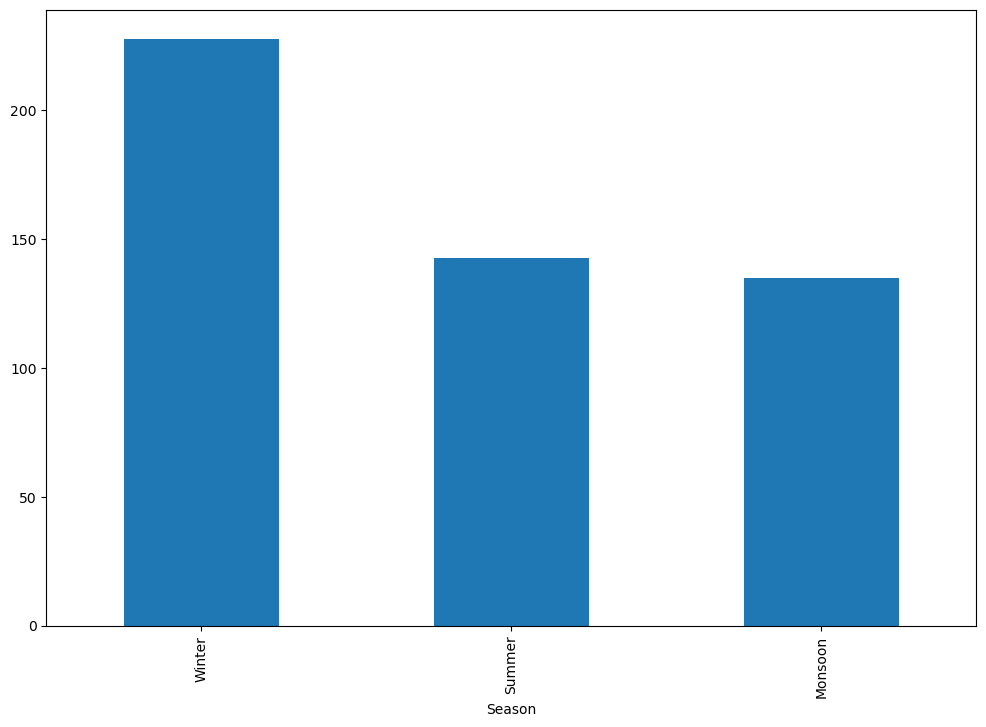

In [45]:
season_aqi = df_day.groupby('Season')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
season_aqi.plot(kind='bar')
plt.xticks(rotation=90)
plt.show()

### Observation
This plot shows winter has the highest average AQI and monsoon has the lowest. So air quality looks worse in winter in this dataset.



In [46]:
from scipy.stats import kruskal

season_groups = [group['AQI'].dropna() for _, group in df_day.groupby('Season')]
stat, p_value = kruskal(*season_groups)
print('Kruskal-Wallis statistic:', stat)
print('p-value:', p_value)

if p_value < 0.05:
    print('Conclusion: AQI changes by season in a meaningful way.')
else:
    print('Conclusion: The season difference may be due to random variation.')

Kruskal-Wallis statistic: 3082.756409743468
p-value: 0.0
Conclusion: AQI changes by season in a meaningful way.


### Observation
Since the AQI distribution is skewed, using Kruskal-Wallis is a better choice than a normal ANOVA here. If the p-value is below 0.05, we can say season has a real effect on AQI in this data.



## Final Conclusion
Xylene was dropped because too many values were missing.

Rows with almost all missing pollution values were removed so the analysis stays useful.

After cleaning and filling missing values, city-wise and season-wise AQI patterns became easier to see.

Winter shows the worst average AQI, and monsoon shows the lowest average AQI in this notebook.

The hypothesis test is added only for season because that comparison is important and easy to check clearly.

